In [71]:
import pandas as pd
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
from adjustText import adjust_text
import yaml
from pathlib import Path
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import numpy as np
from scipy.spatial.distance import pdist, squareform


In [37]:
def load_yml_from_folder(folder_path):
    """Return {filename: parsed_yaml} for every .yml file in folder (recursive)."""
    courses = {}
    for path in sorted(Path(folder_path).rglob("*.yml")):
        if str(path.name).startswith("course"):
            try:
                with open(path, encoding="utf-8") as f:
                    data = yaml.safe_load(f)
                courses[str(path)] = data
            except yaml.YAMLError as e:
                print(f"  [WARN] Could not parse {path}: {e}")
    return courses


def extract_row(data,fname) :
    """
    Return (index_key, row_dict) for a single course YAML, or None on error.
    """
    try:
        # --- index ---
        #course_id = str(data["course_title"]["id"])
        #first_teacher = data["teachers"][0]
        #teaching_id = str(first_teacher["module"]["teaching_id"])
        #index_key = f"{course_id}_{teaching_id}"
        index_key=fname.split('/')[-1].split('.')[0][7:]

        # --- columns ---
        credits= data.get("credits", [])
        title=data["course_title"]["name"]
        ssds = data.get("ssds", [""])
        if not ssds:
            ssds=""
        else:
            ssds=ssds[0]

        languages = data.get("languages", [])

        teachers = data.get("teachers", [])

        campi = data.get("campi", [""])
        if len(campi)>1:
            print(campi)
        campi=campi[0]

        programmes = data.get("programmes", [])

        row = {
            "credits":    credits,
            "ssds":       ssds,
            "languages":  languages,
            "teachers":   teachers,
            "campi":      campi,
            "programmes": programmes,
            "title":title
        }
        return index_key, row

    except (KeyError, IndexError, TypeError) as e:
        return None, {"_error": str(e)}


def build_dataframe(folder_path) :
    courses = load_yml_from_folder(folder_path)
    print(f"Found {len(courses)} YML files.")

    rows = {}
    errors = []
    for fname, data in courses.items():
        key, row = extract_row(data,fname)
        if key is None:
            errors.append((fname, row.get("_error", "unknown")))
        else:
            rows[key] = row

    if errors:
        print(f"\n[WARN] {len(errors)} file(s) could not be fully parsed:")
        for fname, err in errors:
            print(f"  {fname}: {err}")

    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index.name = "course_id"
    return df



In [38]:
FOLDER_PATH = "./../data/courses/.files/2025"

In [39]:

metadata = build_dataframe(FOLDER_PATH)

Found 377 YML files.


In [40]:
def parse_column(col): 
    """Return (course_id, teacher_name) from a feature-matrix column label."""
    parts = [p.strip() for p in col.split("|")]
    course_id = parts[0]
    teacher_name = parts[2] if len(parts) >= 3 else ""
    return course_id, teacher_name


def teacher_matches(teacher_name_col, teachers_list):
    """
    True if any teacher in teachers_list matches teacher_name_col.
    teachers_list entries are dicts with a 'name' key  (e.g. {"name": "Barron Cedeno, Luis Alberto", ...})
    or plain strings, depending on how extract_row stored them.
    Comparison is case-insensitive on the surname (first token before the comma).
    """
    col_surname = teacher_name_col.split(",")[0].strip().lower()
    for t in teachers_list:
        name = t["name"] if isinstance(t, dict) else str(t)
        t_surname = name.split(",")[0].strip().lower()
        if col_surname == t_surname:
            return True
    return False


def load_features(features_csv, course_df):
    """
    Load the feature matrix and return a new DataFrame indexed like course_df.

    Rows   : same index as course_df  (course_id_teaching_id)
    Columns: feature rows from the CSV  (transposed)
    """
    feat = pd.read_csv(features_csv, index_col=0)
    # feat is  (features x courses) — transpose so courses are rows
    feat = feat.T  # now (courses x features), index = original column labels

    # Build a mapping: feature-matrix row label -> course_df index key
    col_to_index = {}
    # Pre-build lookup: course_id -> list of (index_key, teachers)
    id_to_rows: dict[str, list[tuple[str, list]]] = {}
    for idx in course_df.index:
        cid = idx.split("-")[0]
        id_to_rows.setdefault(cid, []).append((idx, course_df.at[idx, "teachers"]))

    unmatched = []
    for col_label in feat.index:
        course_id, teacher_name = parse_column(col_label)
        candidates = id_to_rows.get(course_id, [])
        matched_key = None
        for idx_key, teachers in candidates:
            if teacher_matches(teacher_name, teachers):
                matched_key = idx_key
                break
        if matched_key:
            col_to_index[col_label] = matched_key
        else:
            unmatched.append(col_label)

    if unmatched:
        print(f"[WARN] {len(unmatched)} feature-matrix columns could not be matched:")
        for u in unmatched[:20]:
            print(f"  {u}")
        if len(unmatched) > 20:
            print(f"  ... and {len(unmatched) - 20} more")

    # Keep only matched rows and rename index
    feat_matched = feat.loc[list(col_to_index.keys())].copy()
    feat_matched.index = [col_to_index[k] for k in feat_matched.index]
    feat_matched.index.name = "course_id_teaching_id"
    
    print(f"\nMatched {len(feat_matched)} / {len(feat)} feature-matrix columns.")

    feat_matched = feat_matched[~feat_matched.index.duplicated(keep='first')]  # option 2: keep first

    print("Unduplicated: ",len(feat_matched))

    return feat_matched




In [41]:
FEATURES_CSV = "course_cluster_matrix193features_fullcourseNames.csv"
features=load_features(FEATURES_CSV, metadata)


Matched 723 / 723 feature-matrix columns.
Unduplicated:  362


In [42]:
metadata["programmes"]

course_id
00269      [{'code': '5834', 'campus': 'Cesena', 'languag...
00819-A    [{'code': '6673', 'campus': 'Cesena', 'languag...
00819-B    [{'code': '6673', 'campus': 'Cesena', 'languag...
00819-C    [{'code': '6007', 'campus': 'Cesena, Imola', '...
00819-D    [{'code': '6060', 'campus': 'Bologna', 'langua...
                                 ...                        
B8836      [{'code': '6824', 'campus': 'Bologna', 'langua...
B8905      [{'code': '6824', 'campus': 'Bologna', 'langua...
B8929      [{'code': '6824', 'campus': 'Bologna', 'langua...
B9254      [{'code': '5984', 'campus': 'Ozzano dell'Emili...
C7674                                                     []
Name: programmes, Length: 377, dtype: object

[('08574-A', 'Operating Systems', 10), ('09730-B', 'Principles of Informatics', 10), ('69661', 'Image Processing And Computer Vision M', 14), ('93322', 'Hardware-Software Design of Iot Systems M', 10), ('B2125', 'Machine Learning and Data Mining M', 10)]


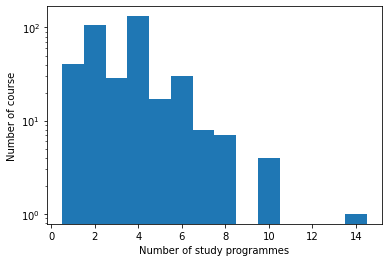

In [47]:
nprog=[len(p) for p in metadata["programmes"]]
plt.hist(nprog, bins=[0.5+i for i in range(max(nprog)+1)])
plt.yscale('log')
plt.ylabel("Number of course")
plt.xlabel("Number of study programmes")

c=[(k,metadata["title"][k], len(metadata["programmes"][k])) for k in metadata["programmes"].index if len(metadata["programmes"][k])>8]
print(c)

In [56]:
metadata = metadata.loc[features.index]
metadata["ssds"].unique()

array(['INF/01', 'ING-INF/05', 'ING-INF/01'], dtype=object)

In [57]:
def plot_tsne_courses(features, metadata, filename,
                      perplexity=30, random_state=42):


    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state
    )

    coords = tsne.fit_transform(features)

    fig, ax = plt.subplots(figsize=(40, 40))

    texts = []

    for i, idx in enumerate(features.index):

        campi = metadata.loc[idx, "campi"]
        ssds = metadata.loc[idx, "ssds"]

        # ----- colour -----
        color = "gray"

        campi_str = str(campi).lower()

        if "cesena" in campi_str:
            color = "green"
        elif "bologna" in campi_str:
            color = "blue"


        # ----- marker -----
        marker = "x"

        ssds_str = str(ssds).upper()

        if "ING-INF/05" in ssds_str:
            marker = "*"
        elif "INF/01" in ssds_str:
            marker = "o"

        ax.scatter(
            coords[i, 0],
            coords[i, 1],
            c=color,
            marker=marker,
            s=120 if marker == "*" else 60,
            alpha=0.8,
        )

        title = metadata.loc[idx, "title"]+ idx

        texts.append(
            ax.text(
                coords[i, 0],
                coords[i, 1],
                title,
                fontsize=8
            )
        )

    adjust_text(
        texts,
        ax=ax,
        force_text=(10, 10),
        force_static=(1,1),
        max_move=10,
        arrowprops=dict(
            arrowstyle="-",
            lw=0.5,
            color="gray"
        )
    )

    ax.set_title("Course t-SNE")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    
    legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='blue', markersize=10,
           label='Bologna INF/01'),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markersize=10,
           label='Cesena INF/01'),

    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='blue', markersize=12,
           label='Bologna ING-INF/05'),

    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='green', markersize=12,
           label='Cesena ING-INF/05'),]

    ax.legend(handles=legend_elements, loc='best')

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close(fig)

In [58]:
plot_tsne_courses(features,metadata, "courses_tsne.png", perplexity=3)

/opt/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/opt/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


In [59]:
def cluster_courses(features, distance_threshold=8.0, filename='clusters.csv'):
    """
    Cluster courses using hierarchical agglomerative clustering.

    Parameters
    ----------
    features : pd.DataFrame
        Feature matrix (rows=courses).

    distance_threshold : float
        Smaller values produce tighter clusters.
        Typical values to try: 5, 6, 7, 8, 10.

    Returns
    -------
    pd.Series
        Cluster labels indexed like features.
    """

    X = StandardScaler().fit_transform(features)

    clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=distance_threshold,linkage="ward",compute_distances=True)

    labels = clustering.fit_predict(X)
    
    cl=pd.Series(labels,index=features.index, name="cluster")
    cl.to_csv(filename)

    return (cl, clustering)

In [60]:
def plot_dendrogram(model, metadata, filename, distance_threshold=None, figsize=(15, 35)):
    """
    Plot a dendrogram from a fitted AgglomerativeClustering model.

    Parameters
    ----------
    model : AgglomerativeClustering
        Fitted clustering model.

    metadata : pd.DataFrame
        Must contain column 'title' in the same order used to fit the model.

    filename : str
        Output image filename.
    """

    # Number of samples under each non-leaf node
    counts = np.zeros(model.children_.shape[0])

    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        count = 0
        for child in merge:
            if child < n_samples:
                count += 1
            else:
                count += counts[child - n_samples]
        counts[i] = count

    # Build linkage matrix
    linkage_matrix = np.column_stack([model.children_, model.distances_,counts ]).astype(float)

    labels = [ f"{idx} - {title}" for idx, title in zip(metadata.index, metadata["title"])]
    
    plt.figure(figsize=figsize)

    dendrogram(linkage_matrix,labels=labels, leaf_font_size=6,
               color_threshold=distance_threshold, orientation='right')

    if distance_threshold is not None:
        plt.axvline(
            x=distance_threshold,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"threshold = {distance_threshold}"
        )
    plt.xlim((-1,plt.xlim()[1]))
    plt.title("Hierarchical clustering of courses")
    plt.xlabel("Courses")
    plt.ylabel("Distance")

    plt.subplots_adjust(right=0.5)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

In [86]:
def plot_distance_scatter(d1, d2, output_file="dist_scatter.png"):
    """
    Compare two distance matrices by plotting the distances of common object pairs.

    Parameters
    ----------
    d1, d2 : pandas.DataFrame
        Symmetric distance matrices with identical row/column labels.
    output_file : str
        Path where the scatterplot will be saved.
    """
    # Find common objects
    common = d1.index.intersection(d2.index)

    # Restrict both matrices to the common objects
    d1c = d1.loc[common, common]
    d2c = d2.loc[common, common]

    # Extract upper triangle (excluding diagonal)
    dist1 = []
    dist2 = []

    for i in range(len(common)):
        for j in range(i + 1, len(common)):
            obj1 = common[i]
            obj2 = common[j]
            dist1.append(d1c.loc[obj1, obj2])
            dist2.append(d2c.loc[obj1, obj2])

    # Create scatterplot
    plt.figure(figsize=(6, 6))
    plt.scatter(dist1, dist2, alpha=0.6)
    r=np.corrcoef(dist1,dist2)[0,1]

    plt.xlabel("Distances on embeddings")
    plt.ylabel("Distances on features")
    plt.title(f"Distance comparison ({len(dist1)} common pairs): r= {r}")
    plt.tight_layout()

    # Save figure
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.close()


In [61]:
d=10
clusters, model = cluster_courses(features, distance_threshold=d)




Text(0, 0.5, 'Number of clusters')

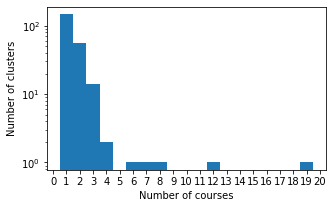

In [63]:
clusters.value_counts().plot.hist(bins=[x +0.5 for x in range(20)],logy=True,xticks=range(21), figsize=(5,3))
plt.xlabel('Number of courses')
plt.ylabel('Number of clusters')



In [64]:
plot_dendrogram(model,metadata,  "clustering.png",distance_threshold=d)

In [90]:
#compare distances with alternative approach

feature_dist= pd.DataFrame(
    squareform(pdist(features, metric='euclidean')),
    index=features.index,
    columns=features.index
)

embedding_dist=pd.read_csv("./../data/clusters/runs/2025-20260703-114011-agglomerative/distance_matrix.csv", index_col='course_id')

print(len(embedding_dist.index))
print(len(feature_dist.index))

plot_distance_scatter(embedding_dist, feature_dist)



377
362


(array([8.380e+02, 4.000e+00, 4.000e+00, 6.000e+00, 4.000e+00, 2.000e+00,
        2.000e+00, 3.200e+01, 7.000e+01, 3.760e+02, 4.080e+02, 8.840e+02,
        1.126e+03, 1.288e+03, 1.644e+03, 2.790e+03, 3.158e+03, 4.004e+03,
        4.470e+03, 4.852e+03, 6.302e+03, 5.912e+03, 5.968e+03, 6.318e+03,
        5.726e+03, 6.014e+03, 5.970e+03, 5.410e+03, 5.116e+03, 4.656e+03,
        4.404e+03, 3.642e+03, 3.414e+03, 2.894e+03, 2.468e+03, 3.508e+03,
        2.642e+03, 4.704e+03, 4.618e+03, 4.230e+03, 3.240e+03, 1.174e+03,
        1.312e+03, 1.460e+03, 1.218e+03, 5.500e+02, 6.220e+02, 0.000e+00,
        0.000e+00, 1.590e+03]),
 array([  0.        ,   2.82842712,   5.65685425,   8.48528137,
         11.3137085 ,  14.14213562,  16.97056275,  19.79898987,
         22.627417  ,  25.45584412,  28.28427125,  31.11269837,
         33.9411255 ,  36.76955262,  39.59797975,  42.42640687,
         45.254834  ,  48.08326112,  50.91168825,  53.74011537,
         56.56854249,  59.39696962,  62.22539674,  65.05

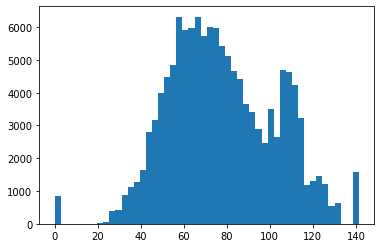

In [94]:
plt.hist(feature_dist.values.flatten(), bins=50)

(array([4.2900e+02, 1.6000e+01, 1.6000e+01, 8.0000e+00, 1.2000e+01,
        8.0000e+00, 1.8000e+01, 1.4000e+01, 2.0000e+01, 2.6000e+01,
        4.6000e+01, 5.6000e+01, 7.0000e+01, 1.3000e+02, 2.4600e+02,
        3.2000e+02, 4.9800e+02, 6.3600e+02, 1.0500e+03, 1.4640e+03,
        1.9020e+03, 2.5340e+03, 3.6600e+03, 4.7700e+03, 5.9840e+03,
        7.3160e+03, 8.5320e+03, 9.4300e+03, 1.0030e+04, 1.0698e+04,
        1.0258e+04, 1.0330e+04, 9.3920e+03, 8.7620e+03, 7.6220e+03,
        6.3660e+03, 5.1880e+03, 4.3980e+03, 3.2800e+03, 2.3560e+03,
        1.6280e+03, 1.1120e+03, 6.9600e+02, 3.4800e+02, 2.0000e+02,
        1.4400e+02, 5.6000e+01, 2.8000e+01, 1.2000e+01, 1.4000e+01]),
 array([0.        , 0.01762898, 0.03525796, 0.05288693, 0.07051591,
        0.08814489, 0.10577387, 0.12340284, 0.14103182, 0.1586608 ,
        0.17628978, 0.19391876, 0.21154773, 0.22917671, 0.24680569,
        0.26443467, 0.28206364, 0.29969262, 0.3173216 , 0.33495058,
        0.35257956, 0.37020853, 0.38783751, 0.

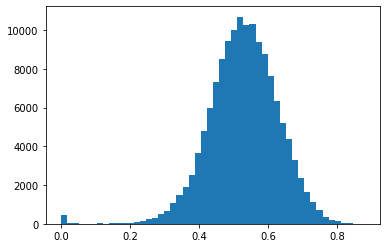

In [95]:
plt.hist(embedding_dist.values.flatten(), bins=50)

In [88]:
377*377

142129

TODO: 
recalculate features

check programme, add columns for teacher dpt,

hypothesis on resources saved for mutuating different distance thresholds (all & only DISI)

Hypothesis on resources saved mutuating modules  (all & only DISI)

    